# AI Agent Trace Pattern Mining

**Objective:** Cluster agent runs by tool use, latency, token consumption, and recovery behavior to identify operational patterns.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["tool_calls", "steps", "input_tokens", "output_tokens", "latency_seconds", "retry_count"]
PROFILE_CENTERS = {
  "direct": [
    2,
    4,
    2200,
    500,
    7,
    0
  ],
  "research": [
    8,
    12,
    7800,
    1700,
    32,
    1
  ],
  "coding": [
    6,
    10,
    5200,
    1250,
    24,
    1
  ],
  "recovery_heavy": [
    10,
    18,
    9200,
    2100,
    58,
    5
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,tool_calls,steps,input_tokens,output_tokens,latency_seconds,retry_count,generator_profile
0,7.688,8.291,4816.044,1172.978,21.958,0.892,coding
1,1.869,4.171,2158.366,516.433,7.253,0.106,direct
2,6.295,9.379,4377.273,1156.922,23.869,1.117,coding
3,8.005,12.538,8708.940,1980.057,32.991,1.059,research
4,2.094,3.787,2109.440,568.132,6.272,0.000,direct


,count,mean,std,min,25%,50%,75%,max
tool_calls,492.0,6.525,3.065,1.407,4.720,6.749,8.997,12.532
steps,492.0,10.919,5.161,3.101,5.129,10.780,13.813,23.507
input_tokens,500.0,6063.936,2746.120,1698.238,3695.485,6338.550,8349.458,11746.041
output_tokens,500.0,1393.500,622.459,371.763,833.814,1430.279,1909.626,2653.296
latency_seconds,500.0,30.277,18.864,5.313,15.845,27.174,40.013,72.921
retry_count,500.0,1.767,1.956,0.000,0.582,1.005,1.906,6.195


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=3 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.6936,0.4161
1,3,0.7422,0.3351
2,4,0.6823,0.4621
3,5,0.5478,1.0265
4,6,0.5456,1.0652


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.7422,0.3351
1,Agglomerative,0.7422,0.3351


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.7131


,records,tool_calls,steps,input_tokens,output_tokens,latency_seconds,retry_count
cluster,,,,,,,
0,125,1.983,3.972,2207.632,499.948,6.968,0.027
1,125,10.077,17.949,9174.318,2119.642,58.277,5.053
2,250,6.959,10.963,6436.898,1477.204,27.932,0.995


cluster,0,1,2,All
generator_profile,,,,
coding,0,0,125,125
direct,125,0,0,125
recovery_heavy,0,125,0,125
research,0,0,125,125
All,125,125,250,500


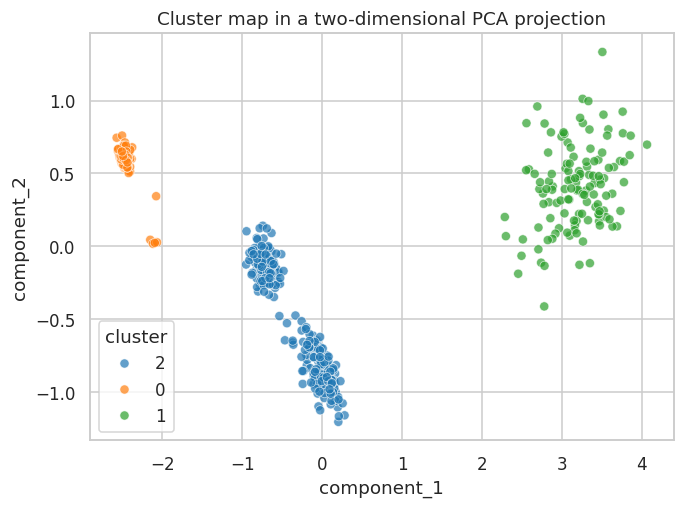

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,tool_calls,steps,input_tokens,output_tokens,latency_seconds,retry_count,predicted_cluster
0,6.749,10.78,6338.55,1430.279,27.174,1.005,2


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
